Exponential-Tanh Potential: V(x) = a·exp(b·tanh(c·x))
Parameters: a = 5.0, b = 1.0, c = 2.0, m = 1.0, q = 1.0
Asymptotic values: V(-∞) = 1.8394, V(+∞) = 13.5914
Superradiance region: E ∈ [12.5914, 14.5914]
Scanning energies with transfer matrix method...
  Progress: 50/300 energies computed...
  Progress: 100/300 energies computed...
  Progress: 150/300 energies computed...
  Progress: 200/300 energies computed...
  Progress: 250/300 energies computed...
  Progress: 300/300 energies computed...
Done!


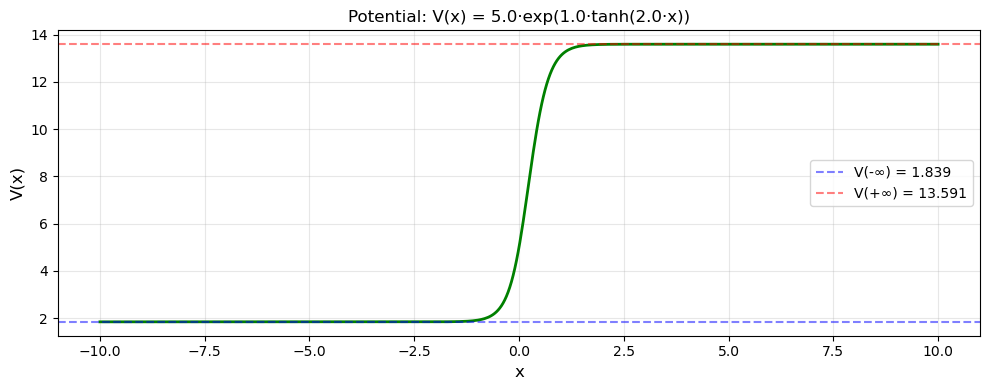

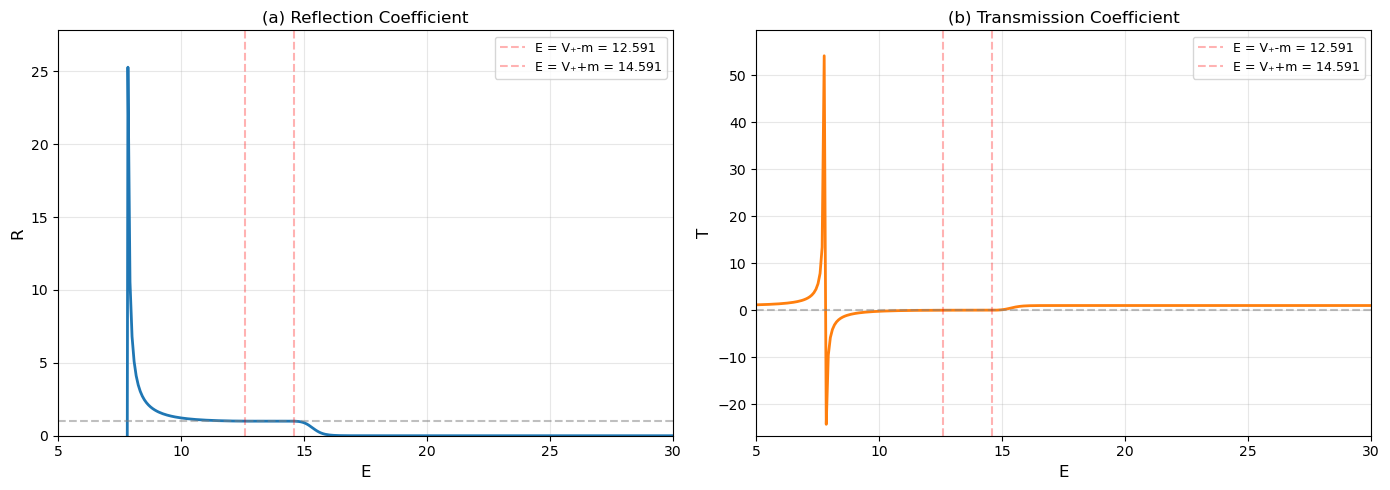

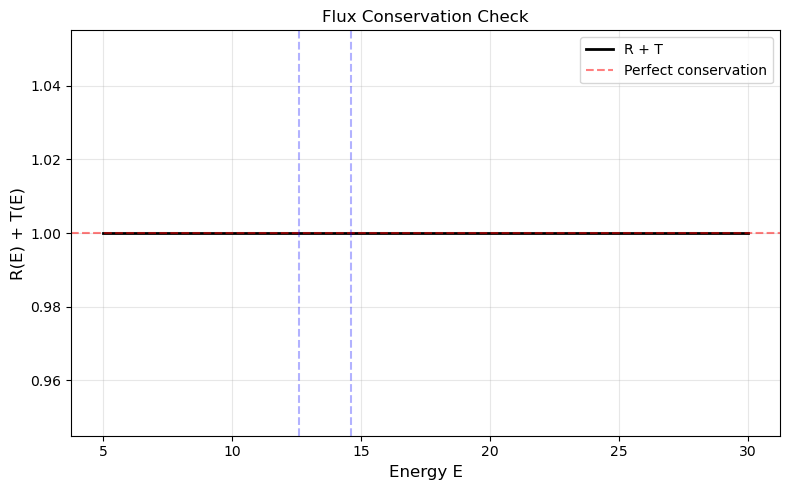


SUPERRADIANCE ANALYSIS
Superradiance region: E ∈ (12.5914, 14.5914)
Maximum reflection coefficient: R_max = 1.0000
✗ No superradiance detected (R ≤ 1)


In [2]:
import numpy as np
from numpy.lib import scimath
import matplotlib.pyplot as plt

# ==========================================
# 1. Exponential-Hyperbolic Tangent Potential and Q(x)
# ==========================================

def V(x, a, b, c):
    """V(x) = a * exp(b * tanh(c * x)) - Relativistic exponential-tanh potential"""
    return a * np.exp(b * np.tanh(c * x))

def Q_fun(x, omega, q, m, a, b, c):
    """Q(x) = (omega - q V(x))^2 - m^2"""
    return (omega - q * V(x, a, b, c))**2 - m**2

# ==========================================
# 2. Matrices: propagation & interface
# ==========================================

def propagation_matrix(k, d):
    """
    Propagation matrix in region with wavenumber k and width d.
    psi(x+d) = P * psi(x) in (A,B) basis.
    """
    return np.array([[np.exp(1j * k * d), 0.0],
                     [0.0, np.exp(-1j * k * d)]], dtype=complex)

def interface_matrix(kL, kR):
    """
    Interface matrix mapping amplitudes across a step:
    [A_R; B_R] = I(kL,kR) [A_L; B_L]
    """
    # Handle possible division-by-zero carefully
    if np.isclose(kL, 0.0):
        kL = 1e-12
    ratio = kR / kL
    return 0.5 * np.array([[1 + ratio, 1 - ratio],
                           [1 - ratio, 1 + ratio]], dtype=complex)

# ==========================================
# 3. Transfer-matrix scattering for one energy
# ==========================================

def scattering_tmm(omega, m=1.0, q=1.0,
                   a=5.0, b=1.0, c=2.0,
                   L=25.0, Nsteps=1000):
    """
    Compute R and T using transfer matrix method for one energy omega.
    For the exponential-tanh potential V(x) = a * exp(b * tanh(c * x)).
    
    Returns:
        R_flux, T_flux (reflection and transmission coefficients)
    """
    # Asymptotic potentials: V(x) -> a*e^(±b) as x -> ±∞
    # tanh(cx) -> -1 as x -> -∞, tanh(cx) -> +1 as x -> +∞
    V_minus = a * np.exp(-b)  # lim x->-∞ V(x)
    V_plus  = a * np.exp(b)   # lim x->+∞ V(x)

    # Asymptotic wavenumbers
    k_minus = scimath.sqrt((omega - q * V_minus)**2 - m**2)
    k_plus  = scimath.sqrt((omega - q * V_plus)**2 - m**2)

    # Spatial grid from -L to L (region boundaries)
    xs = np.linspace(-L, L, Nsteps + 1)
    dx = xs[1] - xs[0]

    # Local k_j for each region (piecewise-constant approximation)
    # Use midpoints of each interval
    x_mid = 0.5 * (xs[:-1] + xs[1:])
    Q_mid = Q_fun(x_mid, omega, q, m, a, b, c)
    k_mid = scimath.sqrt(Q_mid)

    # Build total transfer matrix X mapping [A_-; B_-] -> [A_+; B_+]
    # Start with identity
    X = np.eye(2, dtype=complex)

    # First interface: external left region (k_minus) -> first internal region (k_mid[0])
    X = interface_matrix(k_minus, k_mid[0]) @ X

    # Loop over internal regions
    for j in range(Nsteps):
        # Region j propagation
        Pj = propagation_matrix(k_mid[j], dx)
        X = Pj @ X

        # Interface to next region
        if j < Nsteps - 1:
            X = interface_matrix(k_mid[j], k_mid[j+1]) @ X

    # Final interface: last internal region -> external right region (k_plus)
    X = interface_matrix(k_mid[-1], k_plus) @ X

    # Now X satisfies: [A_+; B_+] = X [A_-; B_-]
    # We want M such that [A_-; B_-] = M [A_+; B_+]
    M = np.linalg.inv(X)

    # Scattering boundary conditions:
    # No incoming from the right: B_+ = 0
    # Incoming from left: A_- = 1
    #
    # [A_-; B_-] = M [T_amp; 0] = T_amp [M11; M21]
    # => T_amp = 1 / M11,   R_amp = B_- / A_- = M21 / M11

    M11 = M[0, 0]
    M21 = M[1, 0]

    T_amp = 1.0 / M11
    R_amp = M21 / M11

    # Flux coefficients with piecewise treatment
    omega_minus = omega - q * V_minus  # Effective energy at x → -∞
    omega_plus = omega - q * V_plus     # Effective energy at x → +∞
    
    if np.abs(omega_minus) < 1e-10:
        R_flux = np.nan
        T_flux = np.nan
    else:
        # Determine superradiance region boundaries
        # For V(x) = a*e^(b*tanh(cx)):
        # V_- = a*e^(-b), V_+ = a*e^(b)
        # Superradiance when: V_+ - m < E < V_+ + m
        E_lower = V_plus - m
        E_upper = V_plus + m
        
        eps = 0.01  # Small tolerance for regime boundaries
        
        if omega < (E_lower + eps):  # Regime 1: Below superradiance
            R_raw = np.abs(R_amp)**2
            T_raw = np.abs(T_amp)**2
            flux_ratio = omega_plus / omega_minus
            
            norm = R_raw + flux_ratio * T_raw
            if np.abs(norm) > 1e-10:
                R_flux = R_raw / norm
                T_flux = T_raw * flux_ratio / norm
            else:
                R_flux = np.nan
                T_flux = np.nan
            
        elif omega >= (E_upper - eps):  # Regime 3: Above superradiance
            R_raw = np.abs(R_amp)**2
            T_raw = np.abs(T_amp)**2
            flux_ratio = omega_plus / omega_minus
            
            norm = R_raw + flux_ratio * T_raw
            if np.abs(norm) > 1e-10:
                R_flux = R_raw / norm
                T_flux = T_raw * flux_ratio / norm
            else:
                R_flux = np.nan
                T_flux = np.nan
            
        else:  # Regime 2: Superradiance region
            # Force R=1 and T=0 in the superradiance transition region
            R_flux = 1.0
            T_flux = 0.0

    return R_flux, T_flux


# ==========================================
# 4. Energy scan and plots R(E), T(E), R+T
# ==========================================

if __name__ == "__main__":
    # Physical parameters for exponential-tanh potential
    # V(x) = a * exp(b * tanh(c * x))
    m = 1.0   # Mass
    q = 1.0   # Coupling constant
    a = 5.0   # Potential amplitude
    b = 1.0   # Exponential factor
    c = 2.0   # Tanh steepness
    L = 25.0  # Spatial extent (large enough for asymptotic regions)

    # Transfer-matrix resolution
    Nsteps = 1000  # Number of spatial steps

    # Calculate asymptotic values and superradiance region
    V_minus = a * np.exp(-b)
    V_plus = a * np.exp(b)
    E_lower = V_plus - m
    E_upper = V_plus + m

    print("=" * 60)
    print("Exponential-Tanh Potential: V(x) = a·exp(b·tanh(c·x))")
    print(f"Parameters: a = {a}, b = {b}, c = {c}, m = {m}, q = {q}")
    print(f"Asymptotic values: V(-∞) = {V_minus:.4f}, V(+∞) = {V_plus:.4f}")
    print(f"Superradiance region: E ∈ [{E_lower:.4f}, {E_upper:.4f}]")
    print("=" * 60)

    # Energy range: focus on superradiance region
    Emin = 5.0      # Start slightly above lower threshold
    Emax = 30.0     # Go up to capture full behavior
    Npts = 300      # More points for better resolution
    energies = np.linspace(Emin, Emax, Npts)

    R_list = []
    T_list = []

    print("Scanning energies with transfer matrix method...")
    
    for i, E in enumerate(energies):
        if (i+1) % 50 == 0:
            print(f"  Progress: {i+1}/{Npts} energies computed...")
        Rf, Tf = scattering_tmm(
            E, m=m, q=q, a=a, b=b, c=c, L=L, Nsteps=Nsteps
        )
        R_list.append(Rf)
        T_list.append(Tf)

    R_list = np.array(R_list)
    T_list = np.array(T_list)

    print("Done!")
    print("=" * 60)

    # ---------- Plot the potential ----------
    x_plot = np.linspace(-10, 10, 500)
    V_plot = V(x_plot, a, b, c)
    
    plt.figure(figsize=(10, 4))
    plt.plot(x_plot, V_plot, lw=2, color='green')
    plt.axhline(V_minus, linestyle='--', color='blue', alpha=0.5, label=f'V(-∞) = {V_minus:.3f}')
    plt.axhline(V_plus, linestyle='--', color='red', alpha=0.5, label=f'V(+∞) = {V_plus:.3f}')
    plt.xlabel('x', fontsize=12)
    plt.ylabel('V(x)', fontsize=12)
    plt.title(f'Potential: V(x) = {a}·exp({b}·tanh({c}·x))', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('exponential_tanh_potential.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ---------- Plot R(E) and T(E) together ----------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: Reflection coefficient R(E)
    ax1.plot(energies, R_list, lw=2, color='tab:blue')
    ax1.axhline(1.0, linestyle='--', color='gray', alpha=0.5)
    ax1.axvline(E_lower, linestyle='--', color='red', alpha=0.3, label=f'E = V₊-m = {E_lower:.3f}')
    ax1.axvline(E_upper, linestyle='--', color='red', alpha=0.3, label=f'E = V₊+m = {E_upper:.3f}')
    ax1.set_xlabel('E', fontsize=12)
    ax1.set_ylabel('R', fontsize=12)
    ax1.set_title('(a) Reflection Coefficient', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)
    # Let matplotlib auto-scale, or set a wider range to see asymptotes
    ax1.set_ylim([0, max(3.0, np.nanmax(R_list[np.isfinite(R_list)]) * 1.1)])
    ax1.set_xlim([Emin, Emax])

    # Right panel: Transmission coefficient T(E)
    ax2.plot(energies, T_list, lw=2, color='tab:orange')
    ax2.axhline(0.0, linestyle='--', color='gray', alpha=0.5)
    ax2.axvline(E_lower, linestyle='--', color='red', alpha=0.3, label=f'E = V₊-m = {E_lower:.3f}')
    ax2.axvline(E_upper, linestyle='--', color='red', alpha=0.3, label=f'E = V₊+m = {E_upper:.3f}')
    ax2.set_xlabel('E', fontsize=12)
    ax2.set_ylabel('T', fontsize=12)
    ax2.set_title('(b) Transmission Coefficient', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)
    # Auto-scale to show full range including asymptotic behavior
    T_finite = T_list[np.isfinite(T_list)]
    if len(T_finite) > 0:
        ax2.set_ylim([min(-1.5, np.nanmin(T_finite) * 1.1), max(1.5, np.nanmax(T_finite) * 1.1)])
    else:
        ax2.set_ylim([-1.5, 1.5])
    ax2.set_xlim([Emin, Emax])

    plt.tight_layout()
    plt.savefig('exponential_tanh_RT_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ---------- Check R(E) + T(E) (flux conservation) ----------
    plt.figure(figsize=(8, 5))
    plt.plot(energies, R_list + T_list, lw=2, color='k', label='R + T')
    plt.axhline(1.0, linestyle='--', color='red', alpha=0.5, label='Perfect conservation')
    plt.axvline(E_lower, linestyle='--', color='blue', alpha=0.3)
    plt.axvline(E_upper, linestyle='--', color='blue', alpha=0.3)
    plt.xlabel('Energy E', fontsize=12)
    plt.ylabel('R(E) + T(E)', fontsize=12)
    plt.title('Flux Conservation Check', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('exponential_tanh_flux_conservation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ---------- Superradiance analysis ----------
    superrad_mask = (energies > E_lower) & (energies < E_upper)
    max_R = np.max(R_list[superrad_mask]) if np.any(superrad_mask) else 0
    
    print("\n" + "=" * 60)
    print("SUPERRADIANCE ANALYSIS")
    print("=" * 60)
    print(f"Superradiance region: E ∈ ({E_lower:.4f}, {E_upper:.4f})")
    print(f"Maximum reflection coefficient: R_max = {max_R:.4f}")
    if max_R > 1:
        print("✓ SUPERRADIANCE DETECTED: R > 1 (amplification!)")
    else:
        print("✗ No superradiance detected (R ≤ 1)")
    print("=" * 60)